In [1]:
import numpy as np
import pandas as pd
import swc.aeon.io as io
import swc.aeon.io.reader as reader
from swc.aeon.schema.streams import Device
from swc.aeon.schema import core as stream
from swc.aeon.io.reader import Csv
import swc.aeon.io.video as video
import os
from dotmap import DotMap
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import islice
import cv2

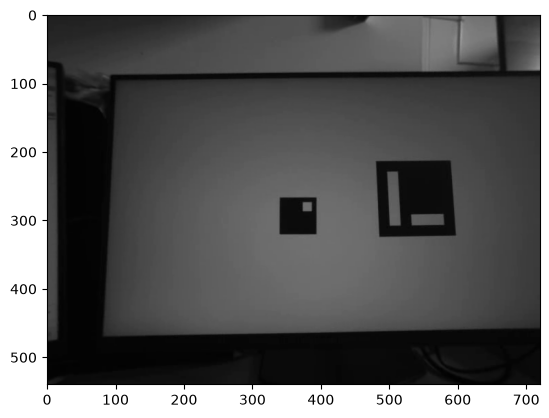

In [247]:
## Extracting camera frames
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T09-28-00/"

def get_camera_data(root: str, name: str):
    path = os.path.join(root, f"{name}/{name}.csv")
    data = pd.read_csv(path, header=0, names=["time"])
    data["_frame"] = data.index
    data["_path"] = os.path.splitext(path)[0] + ".avi"
    data.set_index("time", inplace=True)

    return data

def get_index_at_time(camera_data: pd.DataFrame, time: float):
    slice = camera_data.loc[camera_data.index <= time]
    return slice.iloc[[-1]]["_frame"].values[0]

def get_frame_at_index(camera_data: pd.DataFrame, index: int):
    return next(islice(camera_data, index, index+1))

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

frame = get_frame_at_index(subject_frames, get_index_at_time(subject_camera, 1361.066912))
# frame = get_frame_at_index(subject_frames, get_index_at_time(subject_camera, 1370.4801600000001))

plt.figure()
plt.imshow(frame)

[(array([[340, 267],
       [340, 320],
       [393, 320],
       [394, 267]], dtype=int32), (366, 293)), (array([[589, 212],
       [481, 213],
       [486, 324],
       [597, 322]], dtype=int32), (538, 268))]


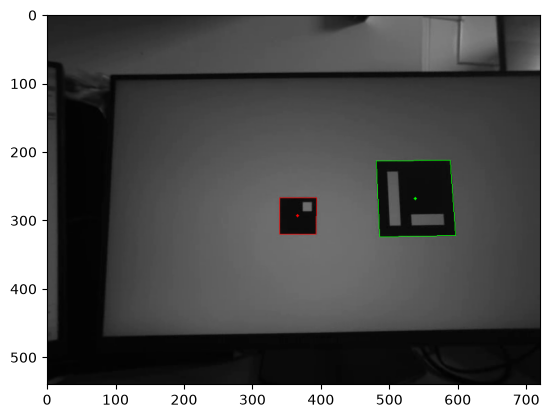

In [248]:
def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs(np.dot(d1, d2) / np.sqrt(np.dot(d1, d1)*np.dot(d2, d2)))

## Landmark detection
def detect_landmarks(frame, blur: int, thresh1: int, thresh2: int):
    blurred = cv2.GaussianBlur(frame, (blur, blur), 0)
    edges = cv2.Canny(blurred, thresh1, thresh2)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    squares = []
    for cnt in contours:
        cnt_len = cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, 0.02 * cnt_len, True)
        if len(cnt) == 4 and cv2.contourArea(cnt) > 1000 and cv2.isContourConvex(cnt):
            cnt = cnt.reshape(-1, 2)
            max_cos = np.max([angle_cos(cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4]) for i in range(4)])
            if max_cos < 0.1:
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                squares.append((cnt, (cx, cy)))

    return squares

squares = detect_landmarks(frame, 1, 200, 100)
print(squares)
track_contour = squares[0] if cv2.contourArea(squares[0][0]) > cv2.contourArea(squares[1][0]) else squares[1]
aruco_contour = squares[1] if cv2.contourArea(squares[0][0]) > cv2.contourArea(squares[1][0]) else squares[0]

contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
contours = cv2.circle(contours, track_contour[1], 2, (0, 255, 0), -1)
contours = cv2.circle(contours, aruco_contour[1], 2, (255, 0, 0), -1)
plt.figure()
plt.imshow(contours)

In [ ]:
## Video run
base_dir = "../../temp_data/sub-Tracking/ses-001_date-2026-07-23T09-28-00/"

subject_camera = get_camera_data(base_dir, "SubjectCamera")
subject_frames = video.frames(subject_camera)

vid_path = os.path.join(base_dir, "AnnotatedResult.mp4")

annotated_frames = []
for frame in subject_frames:
    squares = detect_landmarks(frame, 1, 200, 100)

    if (len(squares) == 2):
        track_contour = squares[0] if (squares[0][1][0] < squares[1][1][0]) else squares[1]
        aruco_contour = squares[1] if (squares[0][1][0] < squares[1][1][0]) else squares[0]
        contours = cv2.drawContours(frame, [track_contour[0]], -1, (0, 255, 0), 1)
        contours = cv2.drawContours(contours, [aruco_contour[0]], -1, (255, 0, 0), 1)
        contours = cv2.circle(contours, track_contour[1], 2, (0, 255, 0), -1)
        contours = cv2.circle(contours, aruco_contour[1], 2, (255, 0, 0), -1)
    else:
        contours = frame

    annotated_frames.append(contours)

video.export(annotated_frames, vid_path, 60)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
